# Constants of Jump model
$$
u_t \sim \mathrm{Bernoulli}(p_t)
$$

$$
\log \frac{p_t}{1-p_t} = \gamma_0 + \sum_{j=1}^p \gamma_j \log S_{t-j} + \omega^T z_t
$$

In [ ]:
# Shared raw data in repository; generated data in this study
from pathlib import Path
import sys

REPO_ROOT = next(
    (
        p
        for p in (Path.cwd(), *Path.cwd().parents)
        if (p / "setup-env.ps1").is_file() and (p / "study_with_me").is_dir()
    ),
    None,
)
if REPO_ROOT is None:
    raise RuntimeError("Run this notebook from inside paper_study.")
PROJECT_DIR = REPO_ROOT / "study_with_me"
RAW_DATA_DIR = REPO_ROOT / "data" / "raw"
PROJECT_DATA_DIR = PROJECT_DIR / "data"
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy
import sklearn
import statsmodels
import seaborn
import statsmodels
import statsmodels.api as sm

print("numpy:", np.__version__)
print("pandas:", pd.__version__)
print("matplotlib", matplotlib.__version__)
print("scipy:", scipy.__version__)
print("sklearn:", sklearn.__version__)
print("statsmodels:", statsmodels.__version__)
print("seaborn:", seaborn.__version__)
print("statsmodels:", statsmodels.__version__)

numpy: 2.4.2
pandas: 3.0.1
matplotlib 3.10.8
scipy: 1.17.1
sklearn: 1.8.0
statsmodels: 0.14.6
seaborn: 0.13.2
statsmodels: 0.14.6


In [2]:
tokyo = pd.read_csv(
    (PROJECT_DATA_DIR / "processed/electricity/price_tokyo.csv"),
    parse_dates=["datetime"],
    index_col="datetime",
)
tokyo36 = tokyo[tokyo["slot"] == 36].copy()
weather = pd.read_csv(
    (PROJECT_DATA_DIR / "features/electricity/temp_features.csv"),
    parse_dates=["time"],
    index_col="time",
)

In [3]:
print(tokyo36.shape)
print(weather.shape)

(3652, 6)
(3652, 14)


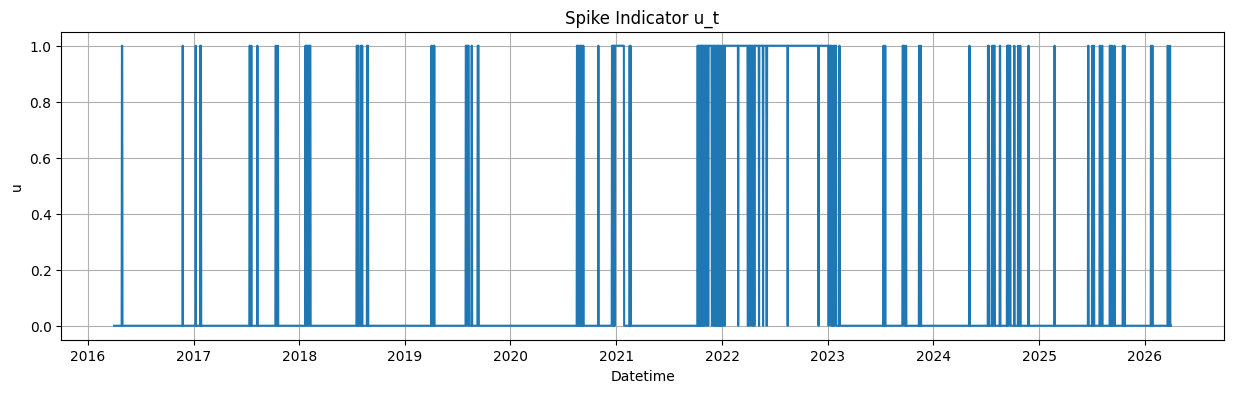

In [4]:
import matplotlib.pyplot as plt

# u の時系列プロット
plt.figure(figsize=(15, 4))

plt.plot(tokyo36.index, tokyo36["u"])

plt.title("Spike Indicator u_t")
plt.xlabel("Datetime")
plt.ylabel("u")

plt.grid(True)
plt.show()

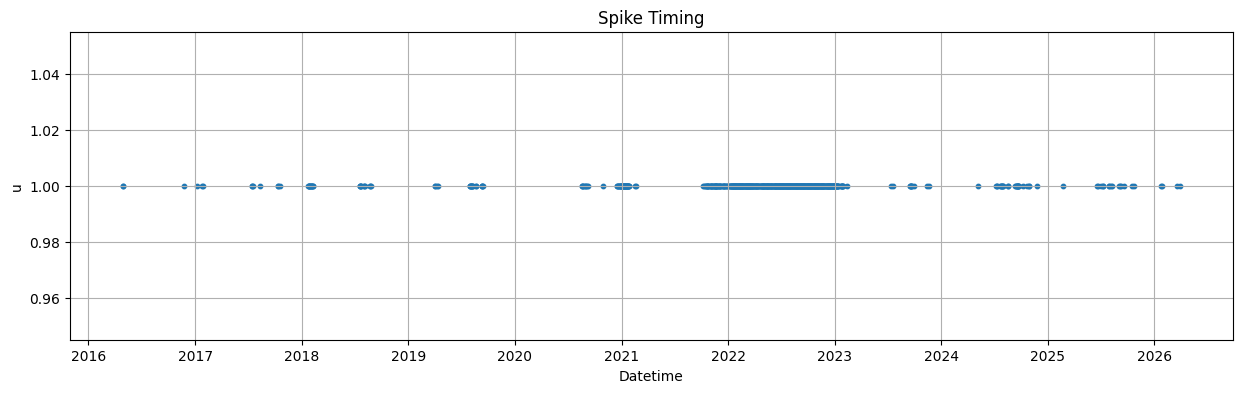

In [5]:
import matplotlib.pyplot as plt

# スパイク発生時刻だけ抽出
spike_df = tokyo36[tokyo36["u"] == 1]

plt.figure(figsize=(15, 4))

plt.scatter(spike_df.index, spike_df["u"], s=10)

plt.title("Spike Timing")
plt.xlabel("Datetime")
plt.ylabel("u")

plt.grid(True)
plt.show()

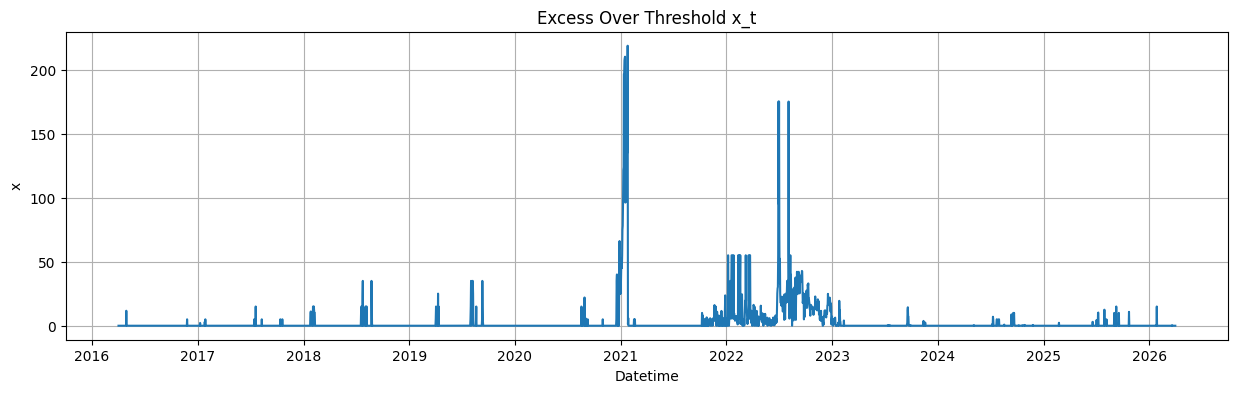

In [6]:
import matplotlib.pyplot as plt

# x の時系列プロット
plt.figure(figsize=(15, 4))

plt.plot(tokyo36.index, tokyo36["x"])

plt.title("Excess Over Threshold x_t")
plt.xlabel("Datetime")
plt.ylabel("x")

plt.grid(True)
plt.show()

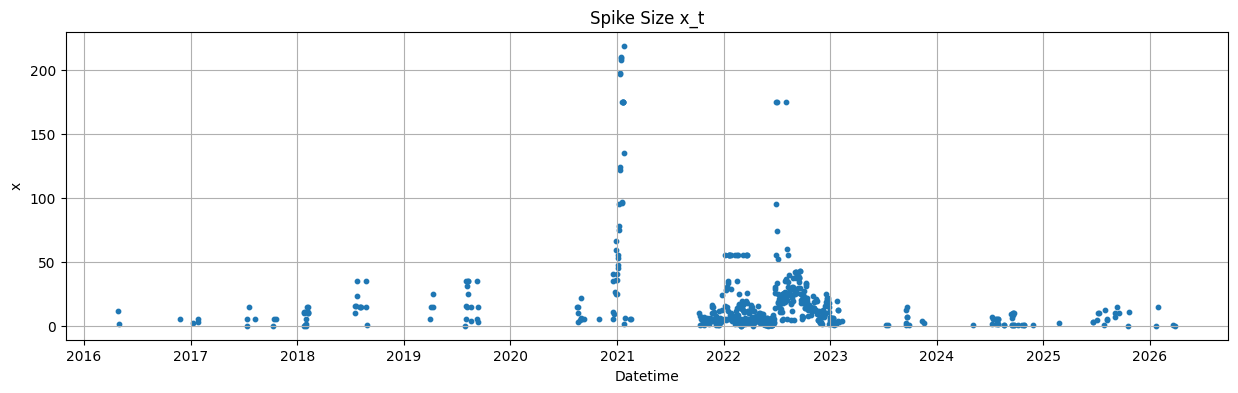

In [7]:
import matplotlib.pyplot as plt

# x > 0 の部分だけ抽出
x_spike = tokyo36[tokyo36["x"] > 0]

plt.figure(figsize=(15, 4))

plt.scatter(x_spike.index, x_spike["x"], s=10)

plt.title("Spike Size x_t")
plt.xlabel("Datetime")
plt.ylabel("x")

plt.grid(True)
plt.show()

# データセット作成

In [8]:
import numpy as np
import pandas as pd

# -------------------------
# 1. データ結合
# -------------------------

# tokyo36 の日付だけを取り出す
price_df = tokyo36.copy()
price_df["date"] = price_df.index.date

weather_df = weather.copy()
weather_df["date"] = weather_df.index.date

# 日付で結合
model_df = pd.merge(price_df, weather_df, on="date", how="inner")

# datetime を index に戻す
model_df.index = tokyo36.index[: len(model_df)]

# -------------------------
# 2. 目的変数を作成
# -------------------------

model_df["log_price"] = np.log(model_df["price_scaled"])

print(model_df.shape)
model_df.head()

(3652, 22)


,slot,is_holiday,price,price_scaled,u,x,date,temp,tmin,tmax,...,snwd,wspd,pres,cldc,temp_mean_past,temp_centered_sq,temp_diff_abs,temp_hot,temp_cold,log_price
datetime,,,,,,,,,,,,,,,,,,,,,
2016-04-01 17:30:00,36,False,10.03,10.030000,0,0.0,2016-04-01,11.7,8.3,18.1,...,NaN,13.7,1020.5,NaN,11.700000,0.000000,NaN,0.0,8.3,2.305581
2016-04-02 17:30:00,36,True,7.49,9.084695,0,0.0,2016-04-02,10.9,7.9,13.3,...,NaN,9.1,1026.3,NaN,11.300000,0.160000,0.8,0.0,9.1,2.206591
2016-04-03 17:30:00,36,True,6.71,8.319092,0,0.0,2016-04-03,13.0,9.7,16.7,...,NaN,10.1,1023.6,NaN,11.866667,1.284444,2.1,0.0,7.0,2.118553
2016-04-04 17:30:00,36,False,9.64,9.640000,0,0.0,2016-04-04,13.9,10.0,21.9,...,NaN,13.3,1008.1,NaN,12.375000,2.325625,0.9,0.0,6.1,2.265921
2016-04-05 17:30:00,36,False,8.74,8.740000,0,0.0,2016-04-05,10.9,9.7,12.3,...,NaN,8.2,1014.0,NaN,12.080000,1.392400,3.0,0.0,9.1,2.167910


In [9]:
def add_log_price(df, price_col="price_scaled"):
    df = df.copy()
    df["log_price"] = np.log(df[price_col])
    return df


def add_lag_features(df, target_col="log_price", p=7):
    df = df.copy()

    for lag in range(1, p + 1):
        df[f"{target_col}_lag{lag}"] = df[target_col].shift(lag)

    return df


def add_fiscal_year(df):
    df = df.copy()

    df["fiscal_year"] = np.where(
        df.index.month >= 4, df.index.year, df.index.year - 1
    ).astype(int)

    return df


def split_train_test_by_fiscal_year(
    df,
    target_col="log_price",
    feature_cols=None,
    p=7,
    n_test_years=2,
):
    if feature_cols is None:
        feature_cols = [
            "temp",
            "temp_centered_sq",
            "temp_diff_abs",
            "temp_hot",
            "temp_cold",
        ]

    lag_cols = [f"{target_col}_lag{lag}" for lag in range(1, p + 1)]

    model_cols = [target_col] + lag_cols + feature_cols

    fiscal_years = sorted(df["fiscal_year"].unique())

    first_fiscal_year = fiscal_years[0]
    test_fiscal_years = fiscal_years[-n_test_years:]
    train_fiscal_years = fiscal_years[1:-n_test_years]

    train_df = df[df["fiscal_year"].isin(train_fiscal_years)].copy()

    test_df = df[df["fiscal_year"].isin(test_fiscal_years)].copy()

    train_df = train_df.dropna(subset=model_cols)
    test_df = test_df.dropna(subset=model_cols)

    info = {
        "first_fiscal_year_removed": first_fiscal_year,
        "train_fiscal_years": train_fiscal_years,
        "test_fiscal_years": test_fiscal_years,
        "target_col": target_col,
        "feature_cols": feature_cols,
        "lag_cols": lag_cols,
        "model_cols": model_cols,
    }

    return train_df, test_df, info

In [10]:
# -------------------------
# 実行
# -------------------------

p = 7

feature_cols = [
    "temp",
    "temp_centered_sq",
    "temp_diff_abs",
    "temp_hot",
    "temp_cold",
]

model_df = (
    model_df
    .pipe(add_log_price, price_col="price_scaled")
    .pipe(add_lag_features, target_col="log_price", p=p)
    .pipe(add_fiscal_year)
)

train_df, test_df, split_info = split_train_test_by_fiscal_year(
    model_df,
    target_col="log_price",
    feature_cols=feature_cols,
    p=p,
    n_test_years=2,
)

print("removed first fiscal year:", split_info["first_fiscal_year_removed"])
print("train fiscal years:", split_info["train_fiscal_years"])
print("test fiscal years :", split_info["test_fiscal_years"])

print("train shape:", train_df.shape)
print("test shape :", test_df.shape)

train_df.head()

removed first fiscal year: 2016
train fiscal years: [np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
test fiscal years : [np.int64(2024), np.int64(2025)]
train shape: (2557, 30)
test shape : (730, 30)


,slot,is_holiday,price,price_scaled,u,x,date,temp,tmin,tmax,...,temp_cold,log_price,log_price_lag1,log_price_lag2,log_price_lag3,log_price_lag4,log_price_lag5,log_price_lag6,log_price_lag7,fiscal_year
datetime,,,,,,,,,,,,,,,,,,,,,
2017-04-01 17:30:00,36,True,11.76,15.671103,0,0.0,2017-04-01,6.7,4.8,8.9,...,13.3,2.751818,2.590017,2.470639,2.494032,2.528126,2.729159,2.816436,2.743498,2017
2017-04-02 17:30:00,36,True,13.39,17.807886,0,0.0,2017-04-02,9.2,4.8,13.9,...,10.8,2.879641,2.751818,2.590017,2.470639,2.494032,2.528126,2.729159,2.816436,2017
2017-04-03 17:30:00,36,False,14.98,14.980000,0,0.0,2017-04-03,9.5,7.4,16.0,...,10.5,2.706716,2.879641,2.751818,2.590017,2.470639,2.494032,2.528126,2.729159,2017
2017-04-04 17:30:00,36,False,13.50,13.500000,0,0.0,2017-04-04,12.3,4.8,17.0,...,7.7,2.602690,2.706716,2.879641,2.751818,2.590017,2.470639,2.494032,2.528126,2017
2017-04-05 17:30:00,36,False,13.00,13.000000,0,0.0,2017-04-05,15.8,7.9,20.3,...,4.2,2.564949,2.602690,2.706716,2.879641,2.751818,2.590017,2.470639,2.494032,2017


In [11]:
train_df.to_csv((PROJECT_DATA_DIR / "model/electricity/train.csv"))
test_df.to_csv((PROJECT_DATA_DIR / "model/electricity/test.csv"))

# ロジスティック回帰
$$
u_t \sim \mathrm{Bernoulli}(p_t)
$$

$$
\log \frac{p_t}{1-p_t} = \gamma_0 + \sum_{j=1}^p \gamma_j \log S_{t-j}
$$

In [12]:
# =========================
# ラグ次数
# =========================

p = 7

In [13]:
train_df.head(10)

,slot,is_holiday,price,price_scaled,u,x,date,temp,tmin,tmax,...,temp_cold,log_price,log_price_lag1,log_price_lag2,log_price_lag3,log_price_lag4,log_price_lag5,log_price_lag6,log_price_lag7,fiscal_year
datetime,,,,,,,,,,,,,,,,,,,,,
2017-04-01 17:30:00,36,True,11.76,15.671103,0,0.0,2017-04-01,6.7,4.8,8.9,...,13.3,2.751818,2.590017,2.470639,2.494032,2.528126,2.729159,2.816436,2.743498,2017
2017-04-02 17:30:00,36,True,13.39,17.807886,0,0.0,2017-04-02,9.2,4.8,13.9,...,10.8,2.879641,2.751818,2.590017,2.470639,2.494032,2.528126,2.729159,2.816436,2017
2017-04-03 17:30:00,36,False,14.98,14.980000,0,0.0,2017-04-03,9.5,7.4,16.0,...,10.5,2.706716,2.879641,2.751818,2.590017,2.470639,2.494032,2.528126,2.729159,2017
2017-04-04 17:30:00,36,False,13.50,13.500000,0,0.0,2017-04-04,12.3,4.8,17.0,...,7.7,2.602690,2.706716,2.879641,2.751818,2.590017,2.470639,2.494032,2.528126,2017
2017-04-05 17:30:00,36,False,13.00,13.000000,0,0.0,2017-04-05,15.8,7.9,20.3,...,4.2,2.564949,2.602690,2.706716,2.879641,2.751818,2.590017,2.470639,2.494032,2017
2017-04-06 17:30:00,36,False,13.39,13.390000,0,0.0,2017-04-06,17.3,13.2,21.0,...,2.7,2.594508,2.564949,2.602690,2.706716,2.879641,2.751818,2.590017,2.470639,2017
2017-04-07 17:30:00,36,False,13.50,13.500000,0,0.0,2017-04-07,17.2,15.6,21.3,...,2.8,2.602690,2.594508,2.564949,2.602690,2.706716,2.879641,2.751818,2.590017,2017
2017-04-08 17:30:00,36,True,11.98,15.911163,0,0.0,2017-04-08,15.3,12.7,17.7,...,4.7,2.767021,2.602690,2.594508,2.564949,2.602690,2.706716,2.879641,2.751818,2017
2017-04-09 17:30:00,36,True,11.09,14.698213,0,0.0,2017-04-09,12.1,12.0,15.1,...,7.9,2.687726,2.767021,2.602690,2.594508,2.564949,2.602690,2.706716,2.879641,2017


In [14]:
# =========================
# 使用カラム
# =========================

lag_cols = [f"log_price_lag{lag}" for lag in range(1, p + 1)]

In [15]:
print(lag_cols)

['log_price_lag1', 'log_price_lag2', 'log_price_lag3', 'log_price_lag4', 'log_price_lag5', 'log_price_lag6', 'log_price_lag7']


In [16]:
print(train_df.shape)
print(test_df.shape)

(2557, 30)
(730, 30)


In [17]:
# =========================
# 欠損除去
# =========================

use_cols = lag_cols + ["u"]

train_model = train_df[use_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()
test_model = test_df[use_cols].replace([np.inf, -np.inf], np.nan).dropna().copy()

print(train_model.shape)
print(test_model.shape)

(2557, 8)
(730, 8)


In [18]:
# =========================
# 学習データ
# =========================

X_train = sm.add_constant(train_model[lag_cols])

y_train = train_model["u"]

# =========================
# ロジスティック回帰
# =========================

logit_model = sm.Logit(y_train, X_train)

result = logit_model.fit()

# =========================
# 結果確認
# =========================

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.177606
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                      u   No. Observations:                 2557
Model:                          Logit   Df Residuals:                     2549
Method:                           MLE   Df Model:                            7
Date:                Mon, 25 May 2026   Pseudo R-squ.:                  0.6498
Time:                        12:11:33   Log-Likelihood:                -454.14
converged:                       True   LL-Null:                       -1296.8
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const            -20.6844      0.916    -22.593      0.000     -22.479     -18.890
log_price_lag1   

In [19]:
print("AIC :", result.aic)
print("BIC :", result.bic)

AIC : 924.27518359098
BIC : 971.0479033933094


In [20]:
from sklearn.metrics import (
    confusion_matrix,
    recall_score,
    precision_score,
    f1_score,
    classification_report,
)

# =========================
# テストデータ作成
# =========================

X_test = sm.add_constant(test_model[lag_cols])

y_test = test_model["u"]

# =========================
# スパイク確率予測
# =========================

p_pred = result.predict(X_test)

# =========================
# 分類閾値
# =========================

threshold = y_train.mean()

print("threshold :", threshold)

# =========================
# 0/1分類
# =========================

y_pred = (p_pred > threshold).astype(int)

# =========================
# 混同行列
# =========================

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix")
print(cm)

# =========================
# Recallなど
# =========================

print("Recall    :", recall_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("F1 Score  :", f1_score(y_test, y_pred))

# =========================
# 詳細レポート
# =========================

print(classification_report(y_test, y_pred))

threshold : 0.20492764958936252
Confusion Matrix
[[568 114]
 [ 15  33]]
Recall    : 0.6875
Precision : 0.22448979591836735
F1 Score  : 0.3384615384615385
              precision    recall  f1-score   support

           0       0.97      0.83      0.90       682
           1       0.22      0.69      0.34        48

    accuracy                           0.82       730
   macro avg       0.60      0.76      0.62       730
weighted avg       0.92      0.82      0.86       730



実際のスパイク48件のうち33件を検知する、一方で114件も誤警報(FP)

回帰係数として有意ではない、lag = 2,4,5,6を除いたモデルを考える

In [21]:
# =========================
# 使用するラグ
# =========================

lags = [1, 3, 7]

# =========================
# 使用カラム
# =========================

lag_cols = [f"log_price_lag{lag}" for lag in lags]

use_cols = lag_cols + ["u"]

# =========================
# 学習データ
# =========================

X_train = sm.add_constant(train_model[lag_cols])

y_train = train_model["u"]

# =========================
# ロジスティック回帰
# =========================

logit_model = sm.Logit(y_train, X_train)

result = logit_model.fit()

# =========================
# 結果確認
# =========================

print(result.summary())

print("AIC :", result.aic)
print("BIC :", result.bic)

Optimization terminated successfully.
         Current function value: 0.178595
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                      u   No. Observations:                 2557
Model:                          Logit   Df Residuals:                     2553
Method:                           MLE   Df Model:                            3
Date:                Mon, 25 May 2026   Pseudo R-squ.:                  0.6479
Time:                        12:11:33   Log-Likelihood:                -456.67
converged:                       True   LL-Null:                       -1296.8
Covariance Type:            nonrobust   LLR p-value:                     0.000
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const            -20.5561      0.907    -22.659      0.000     -22.334     -18.778
log_price_lag1   

In [22]:
from sklearn.metrics import (
    confusion_matrix,
    recall_score,
    precision_score,
    f1_score,
    classification_report,
)

# =========================
# テストデータ作成
# =========================

X_test = sm.add_constant(test_model[lag_cols])

y_test = test_model["u"]

# =========================
# スパイク確率予測
# =========================

p_pred = result.predict(X_test)

# =========================
# 分類閾値
# =========================

threshold = y_train.mean()

print("threshold :", threshold)

# =========================
# 0/1分類
# =========================

y_pred = (p_pred > threshold).astype(int)

# =========================
# 混同行列
# =========================

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix")
print(cm)

# =========================
# Recallなど
# =========================

print("Recall    :", recall_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("F1 Score  :", f1_score(y_test, y_pred))

# =========================
# 詳細レポート
# =========================

print(classification_report(y_test, y_pred))

threshold : 0.20492764958936252
Confusion Matrix
[[566 116]
 [ 14  34]]
Recall    : 0.7083333333333334
Precision : 0.22666666666666666
F1 Score  : 0.3434343434343434
              precision    recall  f1-score   support

           0       0.98      0.83      0.90       682
           1       0.23      0.71      0.34        48

    accuracy                           0.82       730
   macro avg       0.60      0.77      0.62       730
weighted avg       0.93      0.82      0.86       730



BIC値、Recallが改善されている

誤検知は多い

In [23]:
# =========================
# 実測値
# =========================

actual_u = y_test

# =========================
# 予測確率
# =========================

pred_prob = p_pred

# =========================
# スパイク判定
# =========================

pred_u = y_pred

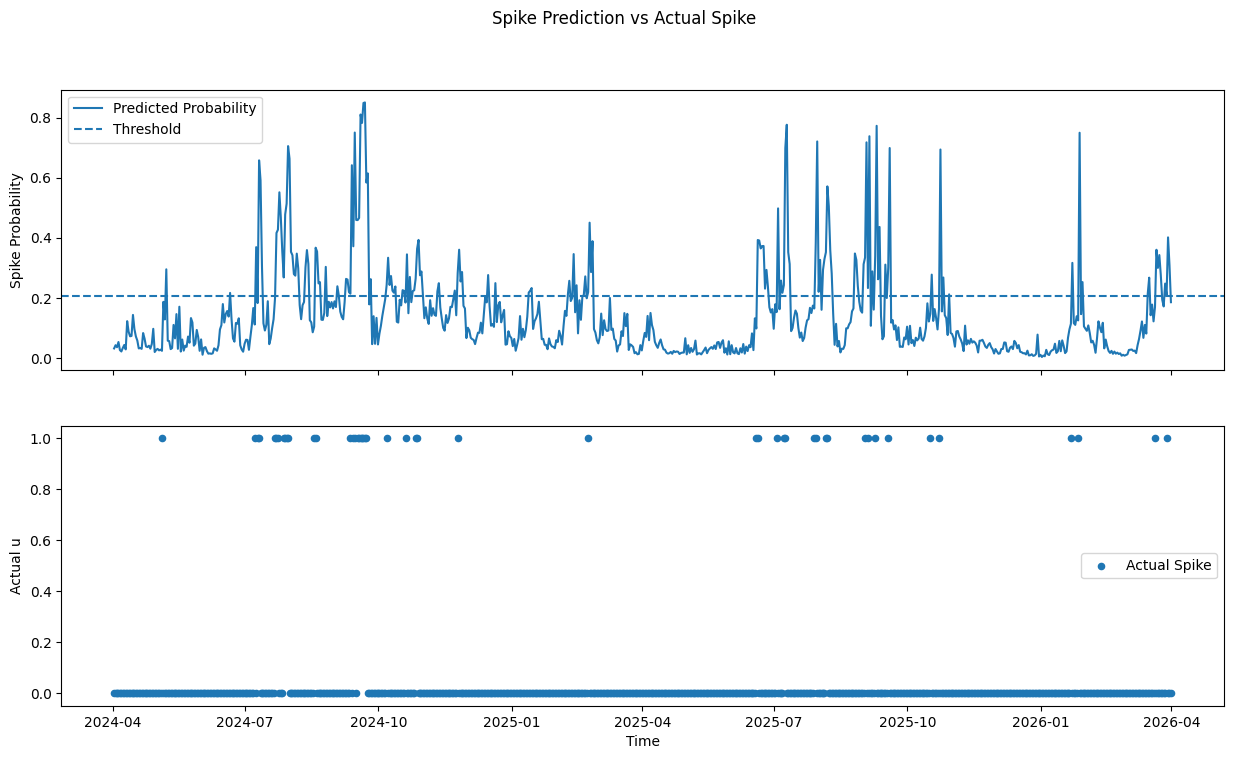

In [24]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# =========================
# 上段: 予測確率
# =========================

axes[0].plot(pred_prob.index, pred_prob, label="Predicted Probability")

axes[0].axhline(threshold, linestyle="--", label="Threshold")

axes[0].set_ylabel("Spike Probability")
axes[0].legend()

# =========================
# 下段: 実測スパイク
# =========================

axes[1].scatter(actual_u.index, actual_u, s=20, label="Actual Spike")

axes[1].set_ylabel("Actual u")
axes[1].set_xlabel("Time")
axes[1].legend()

plt.suptitle("Spike Prediction vs Actual Spike")

plt.show()

気になっている観点はふたつ
- スパイクの初発を検知できているか
- スパイクの終点を検知できているか 

In [25]:
# 過去3日間にスパイクがない初発スパイクと定義する
initial_spike = []

for i in range(len(actual_u)):
    # 最初の3日は判定できないのでFalse
    if i < 3:
        initial_spike.append(False)
        continue

    # 今日スパイク
    today_spike = actual_u.iloc[i] == 1

    # 過去3日間にスパイクがない
    no_recent_spike = actual_u.iloc[i - 3 : i].sum() == 0

    # 初発スパイク
    initial_spike.append(today_spike and no_recent_spike)

# Series化
initial_spike = pd.Series(initial_spike, index=actual_u.index)

# 初発スパイクを当てたか
hit_initial_spike = initial_spike & (pred_u == 1)

initial_recall = hit_initial_spike.sum() / initial_spike.sum()

print(initial_recall)

0.48


> 「すでに価格が高い」→「次も高い」

をモデル化しているに過ぎない

いきなり上がっているものは検知できていない

# 気温という外政変数を加えて初発の検知を試す

In [26]:
train_df.filter(like="temp").head()

,temp,temp_mean_past,temp_centered_sq,temp_diff_abs,temp_hot,temp_cold
datetime,,,,,,
2017-04-01 17:30:00,6.7,16.312022,92.390964,0.5,0.0,13.3
2017-04-02 17:30:00,9.2,16.292643,50.305585,2.5,0.0,10.8
2017-04-03 17:30:00,9.5,16.274185,45.889579,0.3,0.0,10.5
2017-04-04 17:30:00,12.3,16.263415,15.708656,2.8,0.0,7.7
2017-04-05 17:30:00,15.8,16.262162,0.213594,3.5,0.0,4.2


In [27]:
train_model.filter(like="temp").head()

""
datetime
2017-04-01 17:30:00
2017-04-02 17:30:00
2017-04-03 17:30:00
2017-04-04 17:30:00
2017-04-05 17:30:00


In [28]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

from sklearn.metrics import (
    confusion_matrix,
    recall_score,
    precision_score,
    f1_score,
    classification_report,
)

# =========================
# 使用するラグ
# =========================

lags = [1, 3, 7]

# =========================
# 気温変数
# =========================

lag_cols = [f"log_price_lag{lag}" for lag in lags]

weather_cols = [
    "temp_centered_sq",
    #    "temp_diff_abs",
    "temp_hot",
    "temp_cold",
]

X_cols = lag_cols + weather_cols

use_cols = X_cols + ["u"]

# =========================
# 学習データ
# =========================

X_train = sm.add_constant(train_df[X_cols])
y_train = train_df["u"]

X_train.head()


,const,log_price_lag1,log_price_lag3,log_price_lag7,temp_centered_sq,temp_hot,temp_cold
datetime,,,,,,,
2017-04-01 17:30:00,1.0,2.590017,2.494032,2.743498,92.390964,0.0,13.3
2017-04-02 17:30:00,1.0,2.751818,2.470639,2.816436,50.305585,0.0,10.8
2017-04-03 17:30:00,1.0,2.879641,2.590017,2.729159,45.889579,0.0,10.5
2017-04-04 17:30:00,1.0,2.706716,2.751818,2.528126,15.708656,0.0,7.7
2017-04-05 17:30:00,1.0,2.602690,2.879641,2.494032,0.213594,0.0,4.2


In [29]:
# =========================
# ロジスティック回帰
# =========================

logit_model = sm.Logit(y_train, X_train)
result = logit_model.fit()

# =========================
# 推定結果
# =========================

print(result.summary())
print("AIC :", result.aic)
print("BIC :", result.bic)

Optimization terminated successfully.
         Current function value: 0.177144
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                      u   No. Observations:                 2557
Model:                          Logit   Df Residuals:                     2550
Method:                           MLE   Df Model:                            6
Date:                Mon, 25 May 2026   Pseudo R-squ.:                  0.6507
Time:                        12:11:34   Log-Likelihood:                -452.96
converged:                       True   LL-Null:                       -1296.8
Covariance Type:            nonrobust   LLR p-value:                     0.000
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
const              -20.5011      0.939    -21.827      0.000     -22.342     -18.660
log_price_l

In [33]:
result.params

const              -20.501147
log_price_lag1       3.941380
log_price_lag3       1.461131
log_price_lag7       1.035881
temp_centered_sq     0.009990
temp_hot            -0.177921
temp_cold           -0.109100
dtype: float64

In [35]:
coef_df = result.params.to_frame(name="coef")
print(coef_df)

                       coef
const            -20.501147
log_price_lag1     3.941380
log_price_lag3     1.461131
log_price_lag7     1.035881
temp_centered_sq   0.009990
temp_hot          -0.177921
temp_cold         -0.109100


In [36]:
import sys
from pathlib import Path

# 保存先
output_path = PROJECT_DATA_DIR / "para/electricity/para_jump.csv"

# CSV出力
coef_df.to_csv(output_path, encoding="utf-8-sig")

print(f"saved: {output_path}")

saved: ..\data\para\electricity\para_jump.csv


In [30]:
# =========================
# テストデータ予測
# =========================

X_test = sm.add_constant(test_df[X_cols])
y_test = test_df["u"]

p_pred = result.predict(X_test)

# =========================
# 閾値設定
# =========================

threshold = y_train.mean()

y_pred = (p_pred > threshold).astype(int)

# =========================
# 評価
# =========================

cm = confusion_matrix(y_test, y_pred)

print("threshold :", threshold)
print("Confusion Matrix")
print(cm)

print("Recall    :", recall_score(y_test, y_pred))
print("Precision :", precision_score(y_test, y_pred))
print("F1        :", f1_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

threshold : 0.20492764958936252
Confusion Matrix
[[558 124]
 [ 13  35]]
Recall    : 0.7291666666666666
Precision : 0.22012578616352202
F1        : 0.33816425120772947
              precision    recall  f1-score   support

           0       0.98      0.82      0.89       682
           1       0.22      0.73      0.34        48

    accuracy                           0.81       730
   macro avg       0.60      0.77      0.61       730
weighted avg       0.93      0.81      0.85       730



In [31]:
# =========================
# 実測値
# =========================

actual_u = y_test

# =========================
# 予測確率
# =========================

pred_prob = p_pred

# =========================
# スパイク判定
# =========================

pred_u = y_pred

In [32]:
# 過去3日間にスパイクがない初発スパイクと定義する
initial_spike = []

for i in range(len(actual_u)):
    # 最初の3日は判定できないのでFalse
    if i < 3:
        initial_spike.append(False)
        continue

    # 今日スパイク
    today_spike = actual_u.iloc[i] == 1

    # 過去3日間にスパイクがない
    no_recent_spike = actual_u.iloc[i - 3 : i].sum() == 0

    # 初発スパイク
    initial_spike.append(today_spike and no_recent_spike)

# Series化
initial_spike = pd.Series(initial_spike, index=actual_u.index)

# 初発スパイクを当てたか
hit_initial_spike = initial_spike & (pred_u == 1)

initial_recall = hit_initial_spike.sum() / initial_spike.sum()

print(initial_recall)

0.48


初発正解率変化なし